Similar to DESI_tiles_shift.ipynb, set it for JUST case. Scale the rotation angle based on the rotation of field-of-view between JUST and DESI. Take reference from onetile_shift_v1.ipynb. --07-27-2025

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import healpy as hp
from astropy.table import Table
#from matrix_rotation import rotation_matrix_quaternion
#plt.style.use('presentation')

In [ ]:
def rotation_matrix_quaternion(u, v):
    """
    Calculate rotation matrix using quaternion method
    u, v: unit vectors (3-dimensional)
    Returns: 3×3 rotation matrix
    """
    u = u / np.linalg.norm(u)
    v = v / np.linalg.norm(v)
    
    # Compute half-angle vector
    h = (u + v) / np.linalg.norm(u + v)
    
    # Construct quaternion
    q = np.zeros(4)
    q[0] = np.dot(u, h)  # Real component
    q[1:] = np.cross(u, h)  # Imaginary component
    
    # Convert quaternion to rotation matrix
    q = q / np.linalg.norm(q)
    q0, q1, q2, q3 = q
    
    return np.array([
        [1 - 2*(q2*q2 + q3*q3), 2*(q1*q2 - q0*q3), 2*(q1*q3 + q0*q2)],
        [2*(q1*q2 + q0*q3), 1 - 2*(q1*q1 + q3*q3), 2*(q2*q3 - q0*q1)],
        [2*(q1*q3 - q0*q2), 2*(q2*q3 + q0*q1), 1 - 2*(q1*q1 + q2*q2)]
    ])

ipack.3.32762.txt


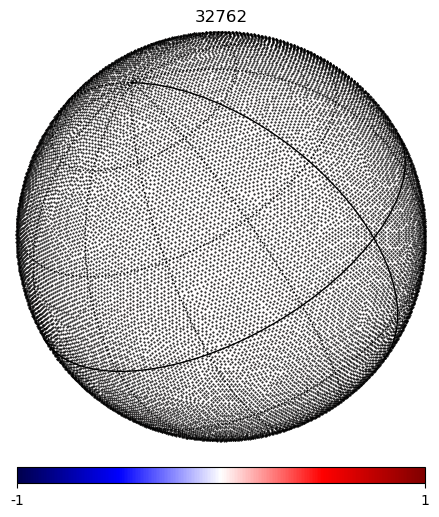

In [2]:
resolution=32762


idir = "/home/zjding/fiberassignment/DESI/footprint/"
filename="ipack.3.%i.txt"%resolution
print(filename)

alltile=np.loadtxt(idir + filename)

length=int(len(alltile)/3)
alltile=alltile.reshape([length,3])
allangle= np.array(hp.vec2ang(alltile)).transpose()

rot=[40,30,30]

data=np.zeros([12])
colormap = "seismic"
hp.orthview(data, cmap=colormap,rot=rot, title="%i"%resolution, half_sky=True)
hp.projscatter(allangle[:,0], allangle[:,1], lonlat=False, marker=".",c="k",s=1)  
hp.graticule()

#plt.savefig('distribution%i.pdf'%resolution, bbox_inches='tight')

## save tile locations with different passes

1.1501736111111112
0.3583095361716857
[[ 0.          0.        ]
 [ 0.91852291  0.61143731]
 [ 1.8999399   0.16500154]
 [ 0.99408323 -0.44768985]
 [ 1.87594391  1.2063028 ]
 [ 0.91044303  1.68173656]
 [ 1.84401136  2.23467625]
 [-0.03241626  1.13458356]
 [ 0.04267825 -1.01704729]
 [-0.90262114 -0.64785589]
 [ 2.76661184  1.77952281]
 [-0.92508356  0.49073716]
 [ 0.96192136 -1.58468484]
 [-0.01271999  2.32839211]
 [ 1.0090104   2.87761972]]


/home/zjding/.local/lib/python3.10/site-packages/healpy-1.17.3-py3.10-linux-x86_64.egg/healpy/projaxes.py:377: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  s = self.scatter(x, y, *args, **kwds)


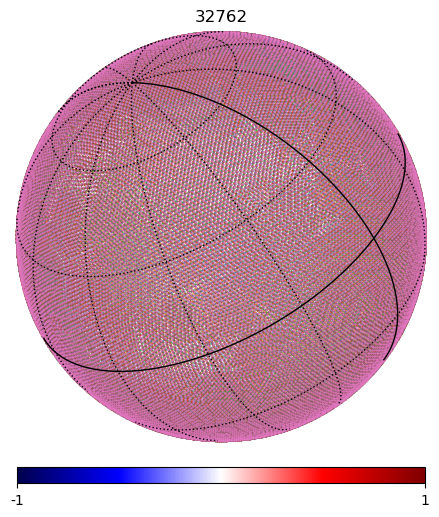

In [3]:
allpass=np.loadtxt(idir + "passrotation.txt")

# JUST field of view (diameter)
just_fov = 530*1.e3/128./3600   # scale factor 128 um/arcsec
print(just_fov)

desi_fov = 1.605 * 2.0 

fov_ratio = just_fov/desi_fov
print(fov_ratio)

allpass *= fov_ratio
print(allpass)

### allpass[:,0]  alpha   lon phi
### allpass[:,1]  delta   lat theta

allpass2=np.empty_like(allpass)
## exchange index to fit healpix convention
allpass2[:,0]=allpass[:,1]+90   ### lat theta
allpass2[:,1]=allpass[:,0]+180   ### lon phi

allpass2=allpass2/180*np.pi

rot=[40,30,30]
colors = mpl.color_sequences["tab10"]

data=np.zeros([12])
colormap = "seismic"
hp.orthview(data, cmap=colormap,rot=rot, title="%i"%resolution, half_sky=True)

source=hp.ang2vec(allpass2[0,0],allpass2[0,1])

tiles_ra = []
tiles_dec = []
tiles_pass = []
for i in range(7):

    target=hp.ang2vec(allpass2[i,0],allpass2[i,1])
    rot=rotation_matrix_quaternion(source,target)
    #print(rot)
    
    alltile2=np.zeros([length,3])
    alltile2[:,0],alltile2[:,1],alltile2[:,2]=hp.rotator.rotateVector(rot, alltile[:,0],alltile[:,1], alltile[:,2])
    allangle2= np.array(hp.vec2ang(alltile2)).transpose()
    # allangle2[:,0] lat theta
    # allangle2[:,1] lon phi
    
    hp.projscatter(allangle2[:,0], allangle2[:,1], lonlat=False, marker=".",c=colors[i],s=1) 

    ra_deg = np.rad2deg(allangle2[:,1])
    dec_deg = 90.0 - np.rad2deg(allangle2[:,0])
    tiles_ra.append(ra_deg)
    tiles_dec.append(dec_deg)
    tiles_pass.append(np.ones(len(ra_deg), dtype=int)*i)

hp.graticule()

#plt.savefig('sphere.pdf', bbox_inches='tight')

In [4]:
output = Table()
output["RA"] = np.concatenate(tiles_ra)
output["DEC"] = np.concatenate(tiles_dec)
output["PASS"] = np.concatenate(tiles_pass)
ofile = "./output/JUST_uniform_tiles.fits"
output.write(ofile, overwrite=True)
output

RA,DEC,PASS
float64,float64,int64
45.174363782311545,11.323050539141434,0
46.379520036802404,11.426781262661692,0
44.684549138201966,10.239008843082686,0
45.88518163747255,10.344646759839279,0
47.585240265125016,11.529096934574866,0
47.08634018109355,10.448905685477769,0
48.79217871926838,11.621925259077202,0
48.28869297014097,10.543713935957527,0
46.89128681646389,12.50196535058943,0


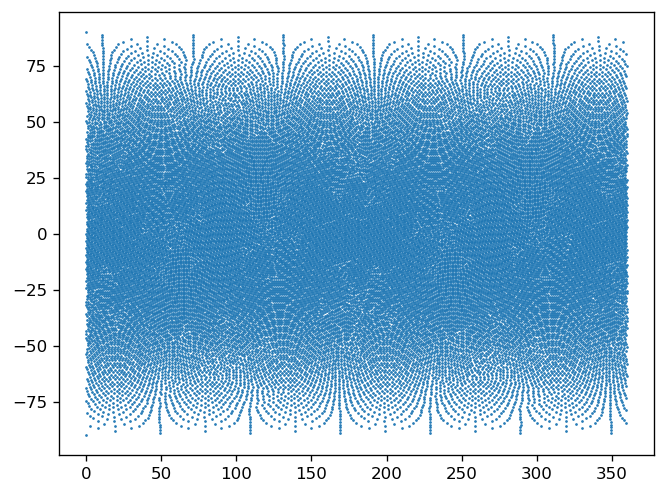

In [5]:
fig, ax = plt.subplots(dpi=120)
mask = output["PASS"]==0
ax.scatter(output["RA"][mask], output["DEC"][mask], marker=".", s=1.5)